In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

# Match the path logic from notebook 01
CWD = Path.cwd()
REPO_ROOT = CWD.parent if CWD.name == "notebooks" else CWD
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
FIG_DIR = REPO_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Consistent style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COVID_COLOR = "#d62728"
ANNOT_STYLE = dict(xycoords="data", fontsize=9, color=COVID_COLOR,
                   arrowprops=dict(arrowstyle="->", color=COVID_COLOR))

print("Processed dir:", PROCESSED_DIR)
print("Exists:", PROCESSED_DIR.exists())

Processed dir: /Users/ganeshsundararaman.arumugam/Desktop/Lecture Notes/Semester 3/6611/V2/Transport/Transport_Decarbonisation_Dashboard_IE/data/processed
Exists: True


In [2]:
fact       = pd.read_csv(PROCESSED_DIR / "fact_transport_annual.csv")
pop        = pd.read_csv(PROCESSED_DIR / "dim_population_annual.csv")
luas       = pd.read_csv(PROCESSED_DIR / "luas_journeys_annual.csv")
pt         = pd.read_csv(PROCESSED_DIR / "public_transport_annual.csv")
car_stock  = pd.read_csv(PROCESSED_DIR / "private_car_stock_annual.csv")
vkm        = pd.read_csv(PROCESSED_DIR / "vehicle_km_annual.csv")
fuel_ann   = pd.read_csv(PROCESSED_DIR / "fuel_mix_new_private_cars_annual.csv")
fuel_mon   = pd.read_csv(PROCESSED_DIR / "fuel_mix_new_private_cars_monthly.csv")
reg_ann    = pd.read_csv(PROCESSED_DIR / "private_car_registrations_annual.csv")
reg_mon    = pd.read_csv(PROCESSED_DIR / "private_car_registrations_monthly.csv")
naptan     = pd.read_csv(PROCESSED_DIR / "naptan_stops_clean.csv")

# Parse dates
fuel_mon["Date"] = pd.to_datetime(fuel_mon["Date"])
reg_mon["Date"]  = pd.to_datetime(reg_mon["Date"])

for name, df in [("fact",fact),("pop",pop),("fuel_ann",fuel_ann),
                 ("reg_ann",reg_ann),("pt",pt),("luas",luas),
                 ("car_stock",car_stock),("vkm",vkm)]:
    print(f"{name:12} {df.shape}   years: {df['Year'].min()}-{df['Year'].max()}")

fact         (8, 22)   years: 2018-2025
pop          (8, 2)   years: 2018-2025
fuel_ann     (12, 12)   years: 2015-2026
reg_ann      (8, 5)   years: 2019-2026
pt           (7, 5)   years: 2019-2025
luas         (8, 3)   years: 2018-2025
car_stock    (6, 3)   years: 2018-2023
vkm          (6, 3)   years: 2018-2023


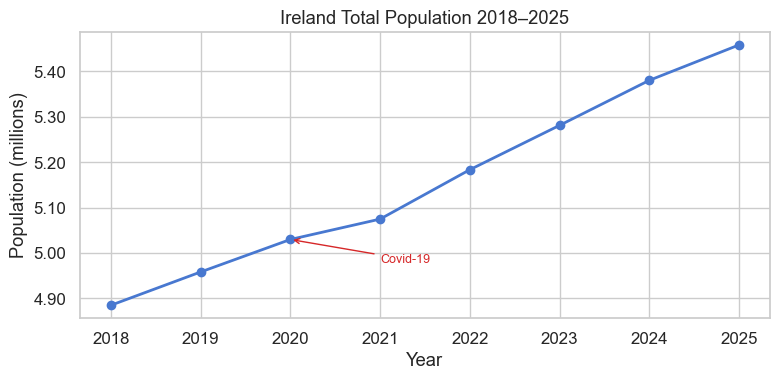

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(pop["Year"], pop["population"] / 1e6, marker="o", linewidth=2)
ax.set(title="Ireland Total Population 2018–2025",
       xlabel="Year", ylabel="Population (millions)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
ax.annotate("Covid-19", xy=(2020, pop.loc[pop.Year==2020,"population"].values[0]/1e6),
            xytext=(2021, pop.loc[pop.Year==2020,"population"].values[0]/1e6 - 0.05),
            **ANNOT_STYLE)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_population_trend.png", dpi=150)
plt.show()

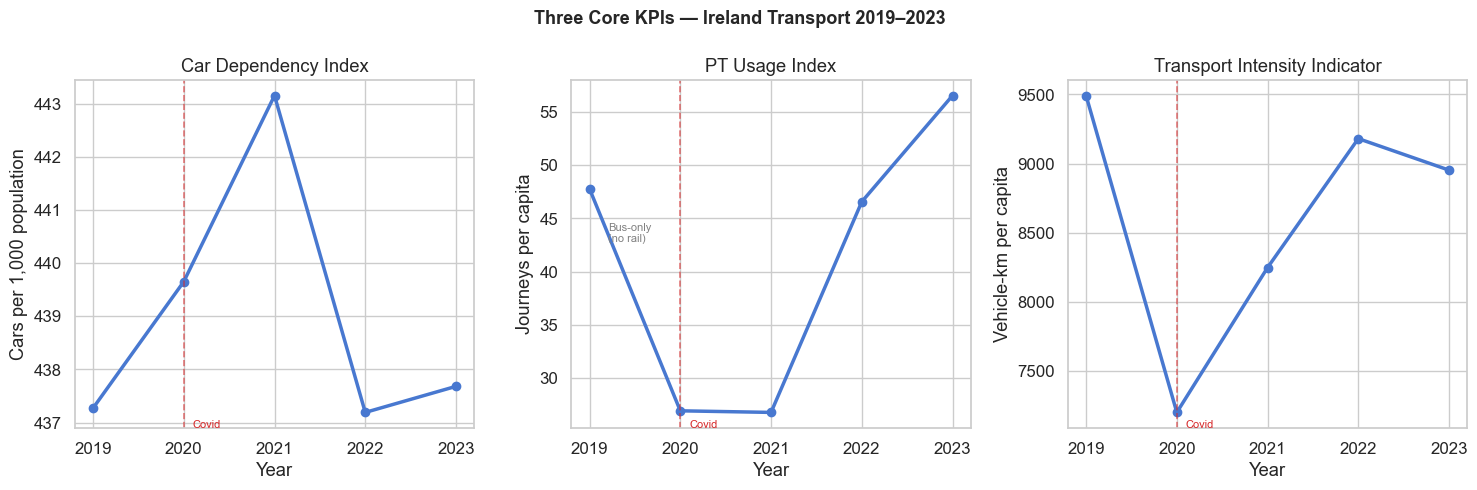

In [4]:
core = fact[fact["in_core_window"]].copy()
kpis = [
    ("car_dependency_index",       "Cars per 1,000 population", "Car Dependency Index"),
    ("pt_usage_index",             "Journeys per capita",        "PT Usage Index"),
    ("transport_intensity_index",  "Vehicle-km per capita",      "Transport Intensity Indicator"),
]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (col, ylabel, title) in zip(axes, kpis):
    ax.plot(core["Year"], core[col], marker="o", linewidth=2.5)
    ax.axvline(2020, color=COVID_COLOR, linestyle="--", alpha=0.6, linewidth=1.2)
    ax.text(2020.1, ax.get_ylim()[0], "Covid", color=COVID_COLOR, fontsize=8)
    ax.set(title=title, xlabel="Year", ylabel=ylabel)
    # annotate 2019 PT caveat for PT Usage
    if col == "pt_usage_index":
        ax.annotate("Bus-only\n(no rail)", xy=(2019, core.loc[core.Year==2019, col].values[0]),
                    xytext=(2019.2, core.loc[core.Year==2019, col].values[0] - 5),
                    fontsize=8, color="grey")
fig.suptitle("Three Core KPIs — Ireland Transport 2019–2023", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "02_three_kpis.png", dpi=150)
plt.show()

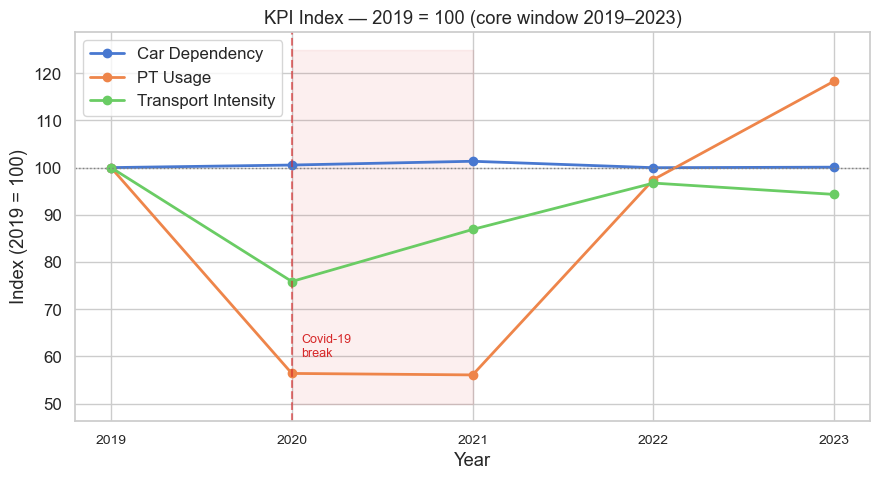

In [6]:
core = fact[fact["in_core_window"]].copy().set_index("Year")
norm_cols = ["car_dependency_index", "pt_usage_index", "transport_intensity_index"]
labels    = ["Car Dependency", "PT Usage", "Transport Intensity"]
base      = core.loc[2019, norm_cols]
normed    = (core[norm_cols] / base * 100)

fig, ax = plt.subplots(figsize=(9, 5))
for col, label in zip(norm_cols, labels):
    ax.plot(normed.index, normed[col], marker="o", linewidth=2, label=label)
ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.axvline(2020, color=COVID_COLOR, linestyle="--", alpha=0.6)
ax.text(2020.05, 60, "Covid-19\nbreak", color=COVID_COLOR, fontsize=9)
ax.fill_betweenx([50, 125], 2020, 2021, alpha=0.07, color=COVID_COLOR)
ax.set_xticks(normed.index)
ax.set_xticklabels([str(y) for y in normed.index], fontsize=10)
ax.set(title="KPI Index — 2019 = 100 (core window 2019–2023)",
       xlabel="Year", ylabel="Index (2019 = 100)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "03_kpis_normalised.png", dpi=150)
plt.show()

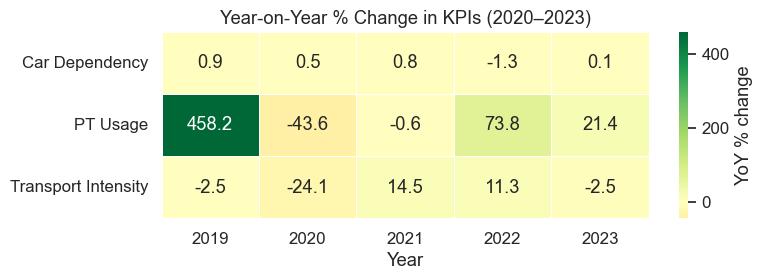

In [7]:
yoy_cols = ["car_dependency_index_yoy_pct",
            "pt_usage_index_yoy_pct",
            "transport_intensity_index_yoy_pct"]
yoy_labels = ["Car Dependency", "PT Usage", "Transport Intensity"]
yoy_df = fact[fact["in_core_window"]].set_index("Year")[yoy_cols].dropna()
yoy_df.columns = yoy_labels

fig, ax = plt.subplots(figsize=(8, 3))
sns.heatmap(yoy_df.T, annot=True, fmt=".1f", center=0,
            cmap="RdYlGn", linewidths=0.5, ax=ax,
            cbar_kws={"label": "YoY % change"})
ax.set(title="Year-on-Year % Change in KPIs (2020–2023)", ylabel="")
plt.tight_layout()
plt.savefig(FIG_DIR / "04_kpi_yoy_heatmap.png", dpi=150)
plt.show()

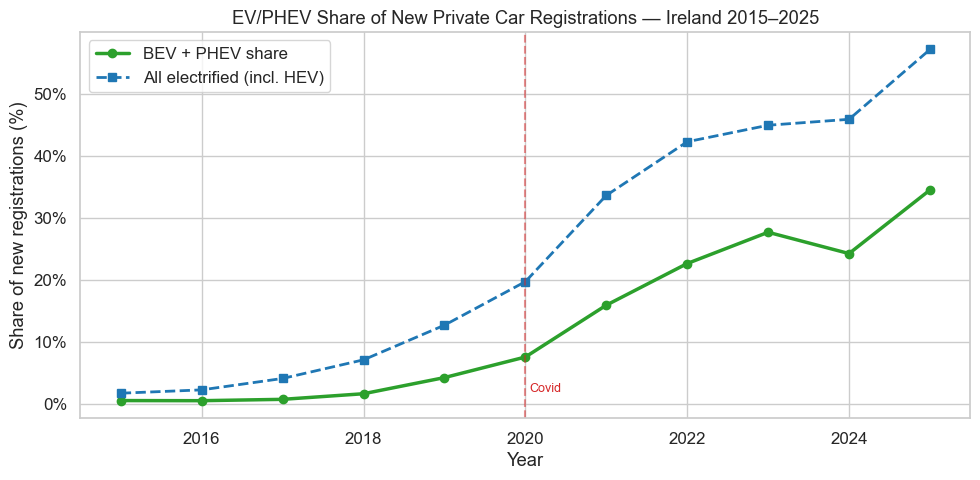

EV+PHEV share: 2015=0.5%  2023=27.6%


In [8]:
complete = fuel_ann[fuel_ann["year_complete"]].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(complete["Year"], complete["ev_phev_share"] * 100,
        marker="o", linewidth=2.5, color="#2ca02c", label="BEV + PHEV share")
ax.plot(complete["Year"], complete["electrified_share"] * 100,
        marker="s", linewidth=2, linestyle="--", color="#1f77b4", label="All electrified (incl. HEV)")
ax.axvline(2020, color=COVID_COLOR, linestyle="--", alpha=0.5)
ax.text(2020.05, 2, "Covid", color=COVID_COLOR, fontsize=9)
ax.set(title="EV/PHEV Share of New Private Car Registrations — Ireland 2015–2025",
       xlabel="Year", ylabel="Share of new registrations (%)")
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "05_ev_phev_share.png", dpi=150)
plt.show()
print(f"EV+PHEV share: 2015={complete.loc[complete.Year==2015,'ev_phev_share'].values[0]*100:.1f}%  "
      f"2023={complete.loc[complete.Year==2023,'ev_phev_share'].values[0]*100:.1f}%")

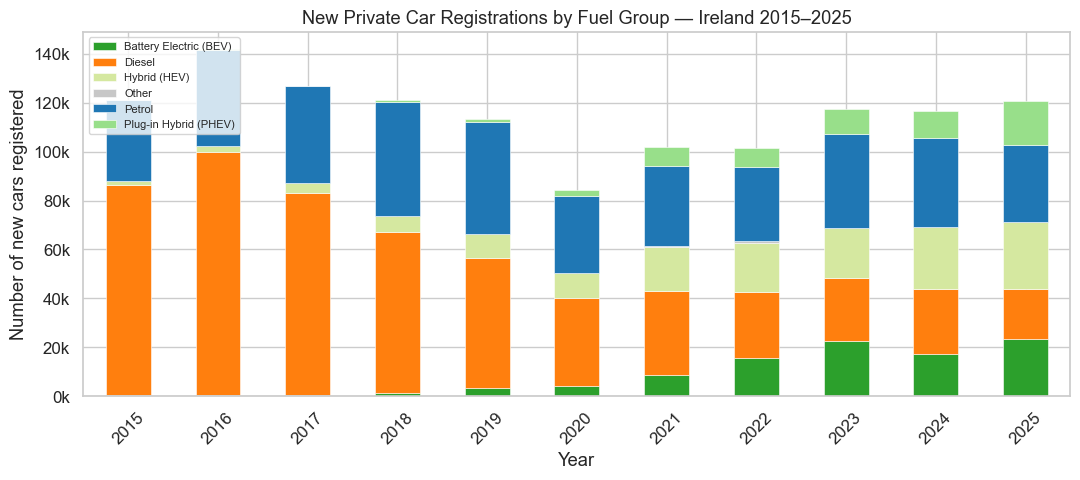

In [9]:
fuel_cols = [c for c in fuel_ann.columns
             if c not in ["Year","total","ev_phev_share","electrified_share",
                          "months_reported","year_complete"]]
palette = {"Petrol":"#1f77b4","Diesel":"#ff7f0e",
           "Battery Electric (BEV)":"#2ca02c","Plug-in Hybrid (PHEV)":"#98df8a",
           "Hybrid (HEV)":"#d5e8a0","Other":"#c7c7c7"}

plot_df = fuel_ann[fuel_ann["year_complete"]][["Year"] + fuel_cols].set_index("Year")
fig, ax = plt.subplots(figsize=(11, 5))
plot_df.plot(kind="bar", stacked=True, ax=ax,
             color=[palette.get(c, "grey") for c in fuel_cols],
             edgecolor="white", linewidth=0.4)
ax.set(title="New Private Car Registrations by Fuel Group — Ireland 2015–2025",
       xlabel="Year", ylabel="Number of new cars registered")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax.legend(loc="upper left", fontsize=8)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "06_fuel_stacked_bar.png", dpi=150)
plt.show()

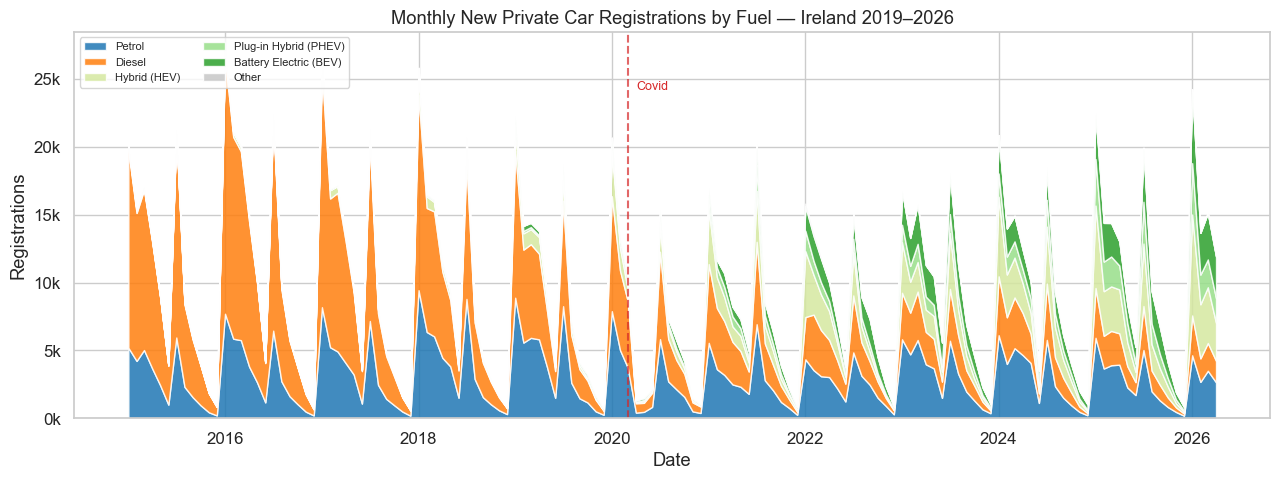

In [10]:
monthly_pivot = (fuel_mon.groupby(["Date","fuel_group"])["new_private_cars"]
                 .sum().unstack(fill_value=0))
col_order = ["Petrol","Diesel","Hybrid (HEV)","Plug-in Hybrid (PHEV)","Battery Electric (BEV)","Other"]
col_order = [c for c in col_order if c in monthly_pivot.columns]
palette_list = ["#1f77b4","#ff7f0e","#d5e8a0","#98df8a","#2ca02c","#c7c7c7"]

fig, ax = plt.subplots(figsize=(13, 5))
ax.stackplot(monthly_pivot.index, [monthly_pivot[c] for c in col_order],
             labels=col_order, colors=palette_list[:len(col_order)], alpha=0.85)
ax.axvline(pd.Timestamp("2020-03-01"), color=COVID_COLOR, linestyle="--", alpha=0.7)
ax.text(pd.Timestamp("2020-04-01"), ax.get_ylim()[1]*0.85, "Covid", color=COVID_COLOR, fontsize=9)
ax.set(title="Monthly New Private Car Registrations by Fuel — Ireland 2019–2026",
       xlabel="Date", ylabel="Registrations")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
ax.legend(loc="upper left", fontsize=8, ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / "07_monthly_fuel_area.png", dpi=150)
plt.show()

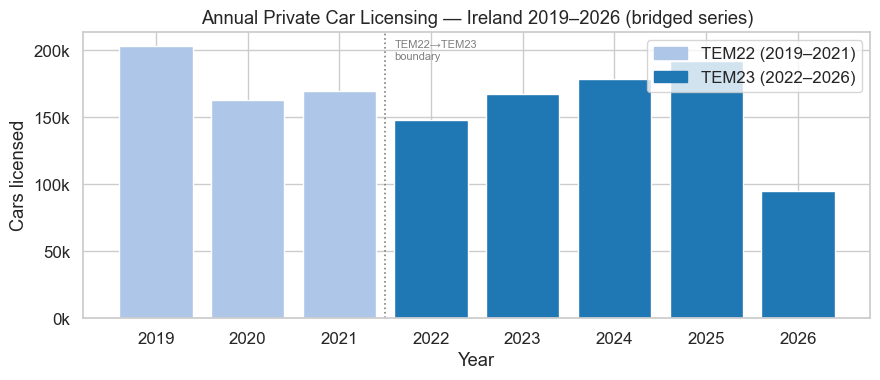

In [11]:
colors = reg_ann["source_table"].map({"TEM22":"#aec7e8","TEM23":"#1f77b4"})
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(reg_ann["Year"], reg_ann["private_cars_licensed"],
              color=colors, edgecolor="white")
ax.axvline(2021.5, color="grey", linestyle=":", linewidth=1.2)
ax.text(2021.6, reg_ann["private_cars_licensed"].max()*0.95,
        "TEM22→TEM23\nboundary", fontsize=8, color="grey")
ax.set(title="Annual Private Car Licensing — Ireland 2019–2026 (bridged series)",
       xlabel="Year", ylabel="Cars licensed")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#aec7e8",label="TEM22 (2019–2021)"),
                   Patch(color="#1f77b4",label="TEM23 (2022–2026)")])
plt.tight_layout()
plt.savefig(FIG_DIR / "08_car_reg_annual.png", dpi=150)
plt.show()

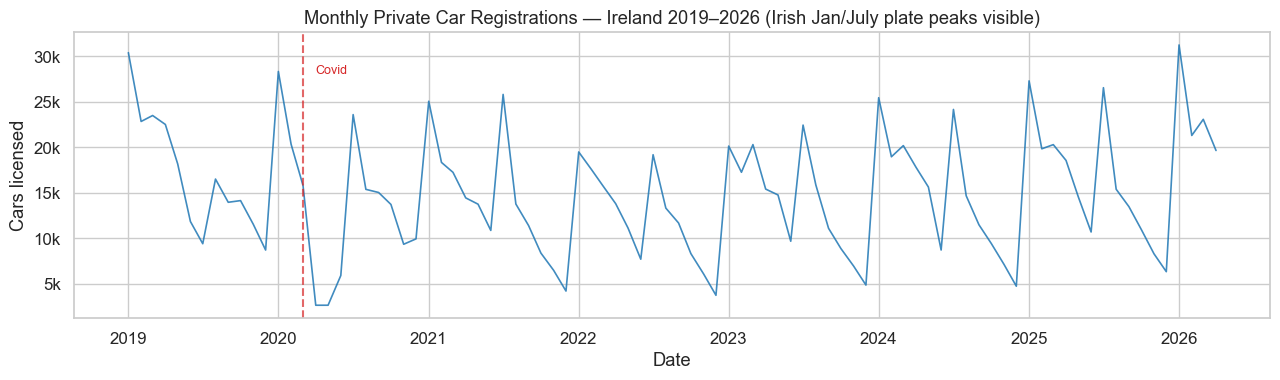

In [12]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(reg_mon["Date"], reg_mon["private_cars_licensed"],
        linewidth=1.2, color="#1f77b4", alpha=0.85)
ax.axvline(pd.Timestamp("2020-03-01"), color=COVID_COLOR, linestyle="--", alpha=0.7)
ax.text(pd.Timestamp("2020-04-01"),
        reg_mon["private_cars_licensed"].max()*0.9, "Covid", color=COVID_COLOR, fontsize=9)
ax.set(title="Monthly Private Car Registrations — Ireland 2019–2026 (Irish Jan/July plate peaks visible)",
       xlabel="Date", ylabel="Cars licensed")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1000:.0f}k"))
plt.tight_layout()
plt.savefig(FIG_DIR / "09_car_reg_monthly.png", dpi=150)
plt.show()

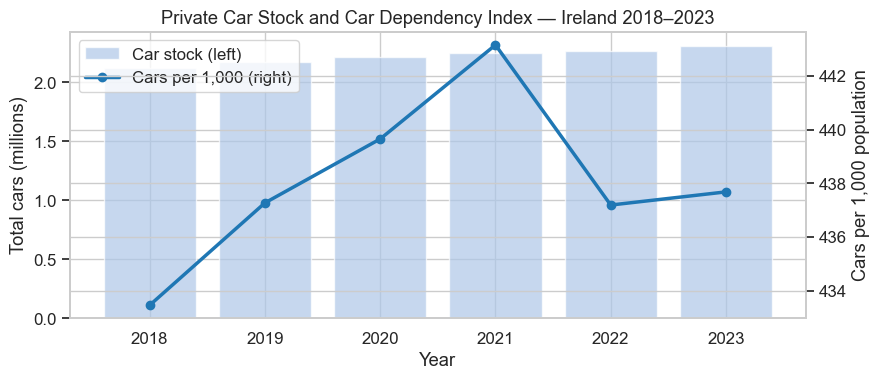

In [13]:
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.bar(car_stock["Year"], car_stock["private_cars"]/1e6,
        color="#aec7e8", alpha=0.7, label="Car stock (left)")
ax2.plot(fact["Year"], fact["car_dependency_index"],
         marker="o", color="#1f77b4", linewidth=2.5, label="Cars per 1,000 (right)")
ax1.set(xlabel="Year", ylabel="Total cars (millions)")
ax2.set_ylabel("Cars per 1,000 population")
ax1.set_title("Private Car Stock and Car Dependency Index — Ireland 2018–2023")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "10_car_stock_dependency.png", dpi=150)
plt.show()

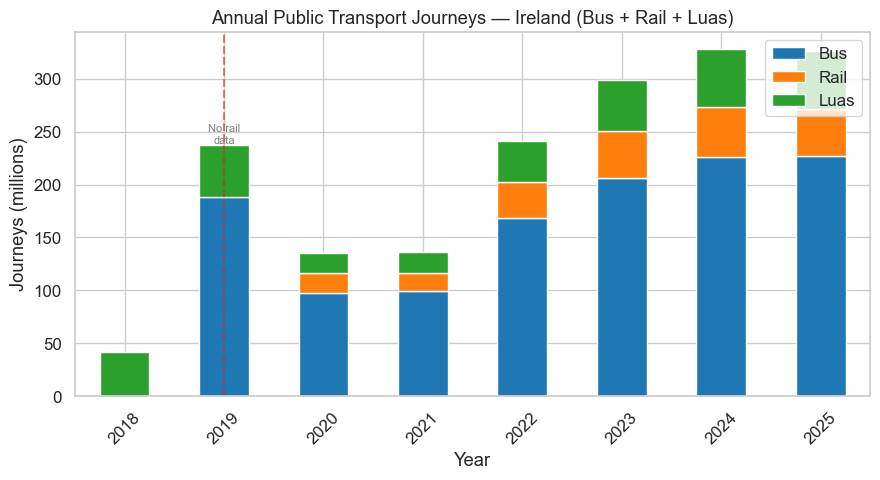

In [14]:
pt_merged = (fact[["Year","bus_journeys","rail_journeys","luas_journeys"]]
             .copy().set_index("Year"))
pt_merged.columns = ["Bus","Rail","Luas"]
pt_merged = pt_merged / 1e6  # millions

fig, ax = plt.subplots(figsize=(9, 5))
pt_merged.plot(kind="bar", stacked=True, ax=ax,
               color=["#1f77b4","#ff7f0e","#2ca02c"], edgecolor="white")
ax.set(title="Annual Public Transport Journeys — Ireland (Bus + Rail + Luas)",
       xlabel="Year", ylabel="Journeys (millions)")
ax.axvline(1.0, color=COVID_COLOR, linestyle="--", alpha=0.6)  # 2020 is index position 1 in 2018-based
# Annotate 2019 rail gap
yr_idx = list(pt_merged.index).index(2019) if 2019 in pt_merged.index else None
if yr_idx is not None:
    ax.text(yr_idx, pt_merged.loc[2019].sum() + 2, "No rail\ndata", ha="center",
            fontsize=8, color="grey")
ax.legend(loc="upper right")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / "11_pt_journeys_stacked.png", dpi=150)
plt.show()

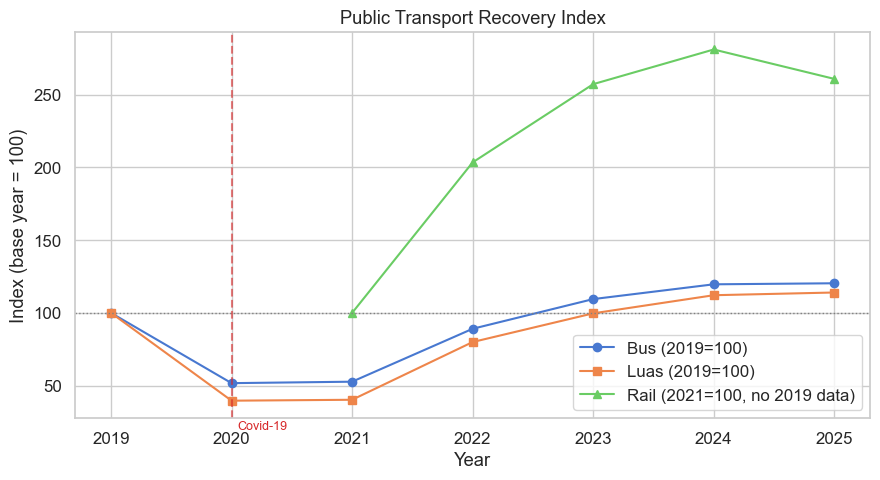

In [15]:
pt_idx = fact[fact["Year"].between(2019, 2025)][["Year","bus_journeys","rail_journeys","luas_journeys"]].copy()
# 2019 base (rail = NaN so we skip rail for 2019 base)
bus_base  = pt_idx.loc[pt_idx.Year==2019,"bus_journeys"].values[0]
luas_base = pt_idx.loc[pt_idx.Year==2019,"luas_journeys"].values[0]
rail_base = pt_idx.loc[pt_idx.Year==2021,"rail_journeys"].values[0]  # first full rail year

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(pt_idx["Year"], pt_idx["bus_journeys"]/bus_base*100,
        marker="o", label="Bus (2019=100)")
ax.plot(pt_idx["Year"], pt_idx["luas_journeys"]/luas_base*100,
        marker="s", label="Luas (2019=100)")
ax.plot(pt_idx.loc[pt_idx.Year>=2021,"Year"],
        pt_idx.loc[pt_idx.Year>=2021,"rail_journeys"]/rail_base*100,
        marker="^", label="Rail (2021=100, no 2019 data)")
ax.axhline(100, color="grey", linestyle=":", linewidth=1)
ax.axvline(2020, color=COVID_COLOR, linestyle="--", alpha=0.6)
ax.text(2020.05, 20, "Covid-19", color=COVID_COLOR, fontsize=9)
ax.set(title="Public Transport Recovery Index", xlabel="Year", ylabel="Index (base year = 100)")
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "12_pt_recovery_index.png", dpi=150)
plt.show()

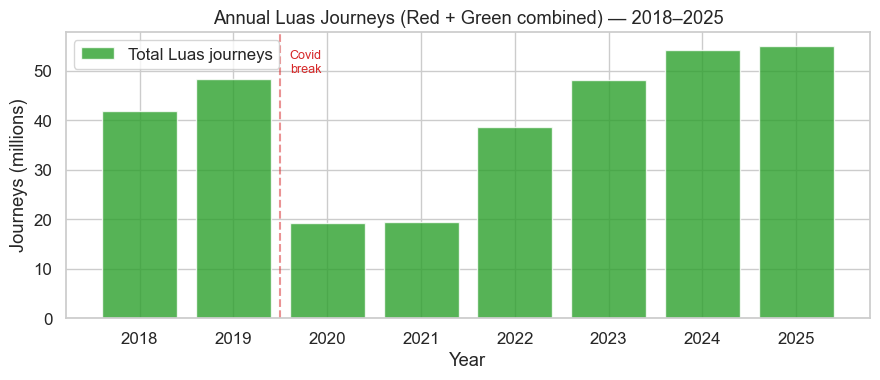

In [16]:
luas_raw = pd.read_csv(PROCESSED_DIR.parent / "raw" / 
                        sorted((PROCESSED_DIR.parent / "raw").glob("TOA11*.csv"))[-1].name
                       ) if False else None
# Use the processed luas file which has both lines summed
# For Red vs Green we re-read from fact via luas processed file
luas_p = pd.read_csv(PROCESSED_DIR / "luas_journeys_annual.csv")
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(luas_p["Year"], luas_p["luas_journeys"]/1e6,
       color="#2ca02c", alpha=0.8, label="Total Luas journeys")
for _, row in luas_p.iterrows():
    if not row["luas_complete"]:
        ax.text(row["Year"], row["luas_journeys"]/1e6 + 0.5, "Incomplete",
                ha="center", fontsize=7, color="grey")
ax.set(title="Annual Luas Journeys (Red + Green combined) — 2018–2025",
       xlabel="Year", ylabel="Journeys (millions)")
ax.axvline(2019.5, color=COVID_COLOR, linestyle="--", alpha=0.5)
ax.text(2019.6, luas_p["luas_journeys"].max()/1e6*0.9, "Covid\nbreak", color=COVID_COLOR, fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "13_luas_annual.png", dpi=150)
plt.show()

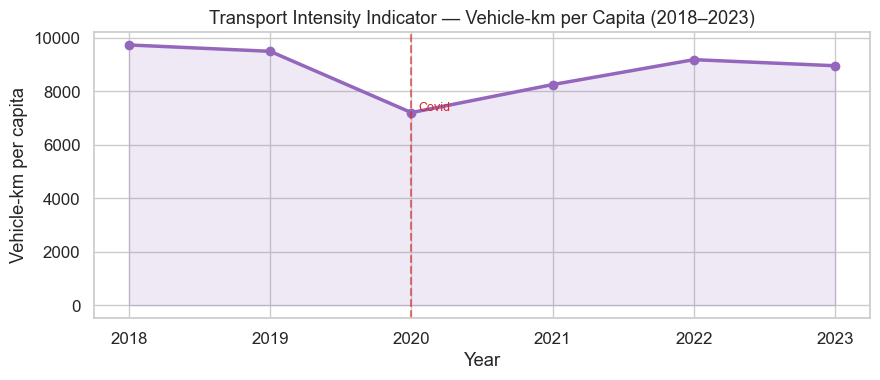

In [17]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fact["Year"], fact["transport_intensity_index"],
        marker="o", linewidth=2.5, color="#9467bd")
ax.axvline(2020, color=COVID_COLOR, linestyle="--", alpha=0.6)
ax.text(2020.05, fact["transport_intensity_index"].min() * 1.01,
        "Covid", color=COVID_COLOR, fontsize=9)
ax.fill_between(fact["Year"], fact["transport_intensity_index"],
                alpha=0.15, color="#9467bd")
ax.set(title="Transport Intensity Indicator — Vehicle-km per Capita (2018–2023)",
       xlabel="Year", ylabel="Vehicle-km per capita")
plt.tight_layout()
plt.savefig(FIG_DIR / "14_transport_intensity.png", dpi=150)
plt.show()

In [18]:
core = fact[fact["in_core_window"]].set_index("Year")
summary = pd.DataFrame({
    "Car Dependency Index": core["car_dependency_index"],
    "PT Usage Index":       core["pt_usage_index"],
    "Transport Intensity":  core["transport_intensity_index"],
    "Period":               core["period_phase"],
    "PT Complete":          core["pt_total_complete"],
})
print("=" * 70)
print("SUMMARY TABLE — Core KPIs 2019–2023")
print("=" * 70)
print(summary.to_string())
print()
print("EV+PHEV share 2019:", f"{fuel_ann.loc[fuel_ann.Year==2019,'ev_phev_share'].values[0]*100:.1f}%")
print("EV+PHEV share 2023:", f"{fuel_ann.loc[fuel_ann.Year==2023,'ev_phev_share'].values[0]*100:.1f}%")
cdi_change = ((core.loc[2023,"car_dependency_index"] - core.loc[2019,"car_dependency_index"])
               / core.loc[2019,"car_dependency_index"] * 100)
print(f"Car Dependency Index change 2019→2023: {cdi_change:+.1f}%")

SUMMARY TABLE — Core KPIs 2019–2023
      Car Dependency Index  PT Usage Index  Transport Intensity                     Period PT Complete
Year                                                                                                  
2019                437.27           47.78               9491.6      Pre-pandemic baseline       False
2020                439.65           26.94               7200.7  Covid-19 structural break        True
2021                443.15           26.79               8247.8  Covid-19 structural break        True
2022                437.19           46.57               9180.3     Post-pandemic recovery        True
2023                437.68           56.54               8952.5     Post-pandemic recovery        True

EV+PHEV share 2019: 4.2%
EV+PHEV share 2023: 27.6%
Car Dependency Index change 2019→2023: +0.1%


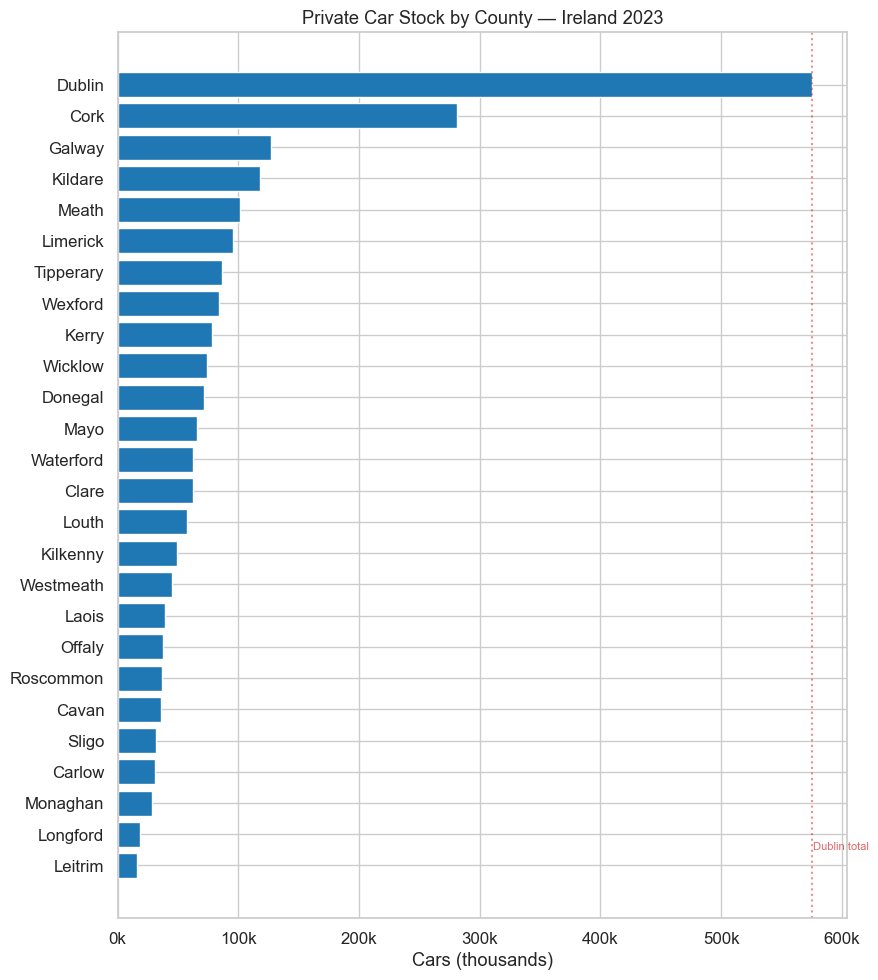

Year: 2023 | Total private cars: 2,311,510


In [20]:
import glob

tha18_path = sorted((REPO_ROOT / "data" / "raw").glob("THA18*.csv"))[-1]
tha18 = pd.read_csv(tha18_path)
tha18.columns = [c.strip() for c in tha18.columns]
tha18["VALUE"] = pd.to_numeric(tha18["VALUE"], errors="coerce")

latest_yr = tha18["Year"].max()

# THA18 is already private cars only — no Type of Vehicle column
county_cars = (tha18[
    (tha18["Statistic Label"] == "Vehicle Population") &
    (tha18["Year"] == latest_yr) &
    (tha18["Year of Registration"] == "All years")
].groupby("County of Ownership", as_index=False)["VALUE"].sum()
 .sort_values("VALUE", ascending=True))

county_cars["County"] = county_cars["County of Ownership"].str.replace("Co. ", "", regex=False)

fig, ax = plt.subplots(figsize=(9, 10))
ax.barh(county_cars["County"], county_cars["VALUE"] / 1000,
        color="#1f77b4", edgecolor="white")
ax.set(title=f"Private Car Stock by County — Ireland {latest_yr}",
       xlabel="Cars (thousands)", ylabel="")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}k"))
dublin_val = county_cars.loc[county_cars["County"].str.contains("Dublin"), "VALUE"].sum()
ax.axvline(dublin_val / 1000, color=COVID_COLOR, linestyle=":", alpha=0.5)
ax.text(dublin_val / 1000 + 0.5, 0.5, "Dublin total",
        fontsize=8, color=COVID_COLOR, alpha=0.7)
plt.tight_layout()
plt.savefig(FIG_DIR / "15_county_car_stock.png", dpi=150)
plt.show()
print(f"Year: {latest_yr} | Total private cars: {county_cars['VALUE'].sum():,.0f}")

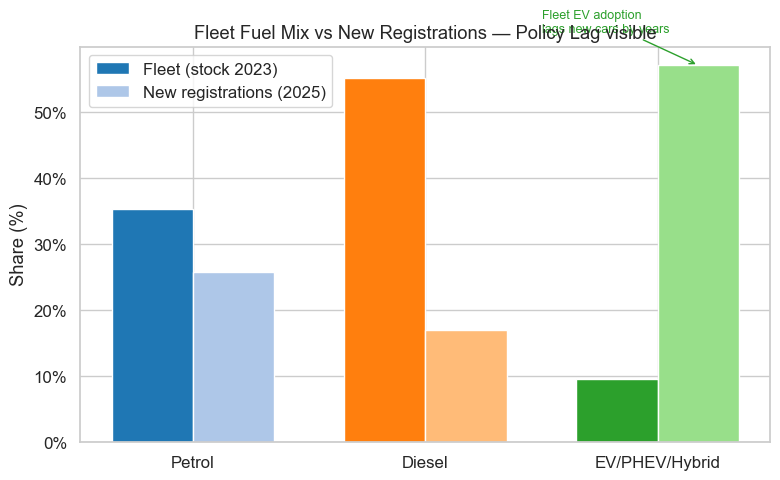

In [21]:
# Fleet fuel mix from THA18 (most recent year)
fleet_fuel = (tha18[
    (tha18["Statistic Label"] == "Vehicle Population") &
    (tha18["Year"] == latest_yr) &
    (tha18["Year of Registration"] == "All years")
].groupby("Fuel Type")["VALUE"].sum())

fleet_fuel = fleet_fuel / fleet_fuel.sum() * 100

# New reg fuel mix from processed fuel_annual (same year or closest)
avail_year = fuel_ann.loc[fuel_ann["year_complete"], "Year"].max()
new_cols = [c for c in fuel_ann.columns
            if c not in ["Year","total","ev_phev_share","electrified_share",
                         "months_reported","year_complete"]]
new_row = fuel_ann.loc[fuel_ann["Year"] == avail_year, new_cols].iloc[0]
new_reg_pct = new_row / new_row.sum() * 100

# Align labels — THA18 has Petrol/Diesel/Other, TEM12 has granular groups
fleet_aligned = pd.Series({
    "Petrol":  fleet_fuel.get("Petrol", 0),
    "Diesel":  fleet_fuel.get("Diesel", 0),
    "EV/PHEV/Hybrid": fleet_fuel.get("Other fuel types", 0),
})
new_aligned = pd.Series({
    "Petrol":  new_reg_pct.get("Petrol", 0),
    "Diesel":  new_reg_pct.get("Diesel", 0),
    "EV/PHEV/Hybrid": (new_reg_pct.get("Battery Electric (BEV)", 0) +
                        new_reg_pct.get("Plug-in Hybrid (PHEV)", 0) +
                        new_reg_pct.get("Hybrid (HEV)", 0)),
})

x = np.arange(len(fleet_aligned))
width = 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, fleet_aligned.values, width,
       label=f"Fleet (stock {latest_yr})", color=["#1f77b4","#ff7f0e","#2ca02c"])
ax.bar(x + width/2, new_aligned.values, width,
       label=f"New registrations ({avail_year})",
       color=["#aec7e8","#ffbb78","#98df8a"])
ax.set_xticks(x)
ax.set_xticklabels(fleet_aligned.index)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set(title="Fleet Fuel Mix vs New Registrations — Policy Lag visible",
       ylabel="Share (%)")
ax.legend()
# Annotate the lag
ax.annotate("Fleet EV adoption\nlags new cars by years",
            xy=(2 + width/2, new_aligned["EV/PHEV/Hybrid"]),
            xytext=(1.5, new_aligned["EV/PHEV/Hybrid"] + 5),
            fontsize=9, color="#2ca02c",
            arrowprops=dict(arrowstyle="->", color="#2ca02c"))
plt.tight_layout()
plt.savefig(FIG_DIR / "16_fleet_vs_newreg_fuel.png", dpi=150)
plt.show()

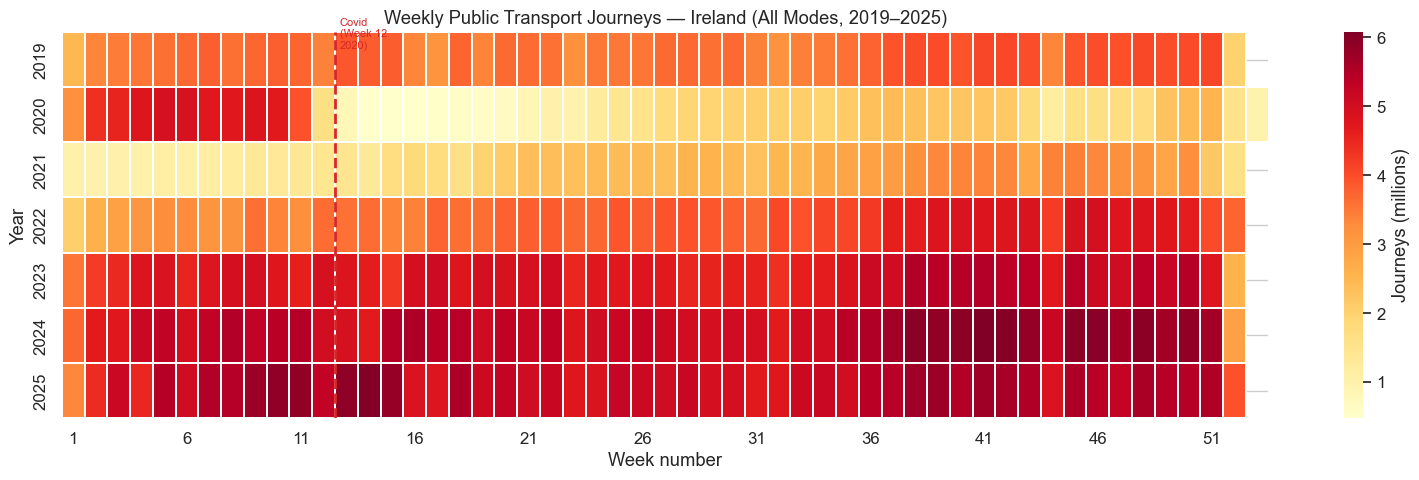

In [24]:
# Read raw THA25
tha25_path = sorted((REPO_ROOT / "data" / "raw").glob("THA25*.csv"))[-1]
tha25 = pd.read_csv(tha25_path)
tha25.columns = [c.strip() for c in tha25.columns]
tha25["VALUE"] = pd.to_numeric(tha25["VALUE"], errors="coerce")

# Parse year and week number
import re
def parse_week_safe(s):
    m = re.fullmatch(r"(\d{4})\s+[Ww]eek\s+(\d{1,2})", str(s).strip())
    return (int(m.group(1)), int(m.group(2))) if m else (None, None)

yw = tha25["Week"].map(parse_week_safe)
tha25["Year"]    = [y for y, _ in yw]
tha25["WeekNum"] = [w for _, w in yw]

# Total all modes per week per year
weekly_total = (tha25.dropna(subset=["Year","WeekNum","VALUE"])
                .groupby(["Year","WeekNum"])["VALUE"].sum(min_count=1)
                .reset_index())

# Pivot: rows = Year, cols = WeekNum
heat = weekly_total.pivot(index="Year", columns="WeekNum", values="VALUE")
heat = heat / 1e6  # millions

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(heat, ax=ax, cmap="YlOrRd",
            linewidths=0.1, linecolor="white",
            cbar_kws={"label": "Journeys (millions)"},
            xticklabels=5)
ax.set(title="Weekly Public Transport Journeys — Ireland (All Modes, 2019–2025)",
       xlabel="Week number", ylabel="Year")
# Mark Covid collapse
ax.axvline(12, color=COVID_COLOR, linewidth=2, linestyle="--")
ax.text(12.2, 0.3, "Covid\n(Week 12\n2020)", color=COVID_COLOR, fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "17_weekly_pt_heatmap.png", dpi=150)
plt.show()

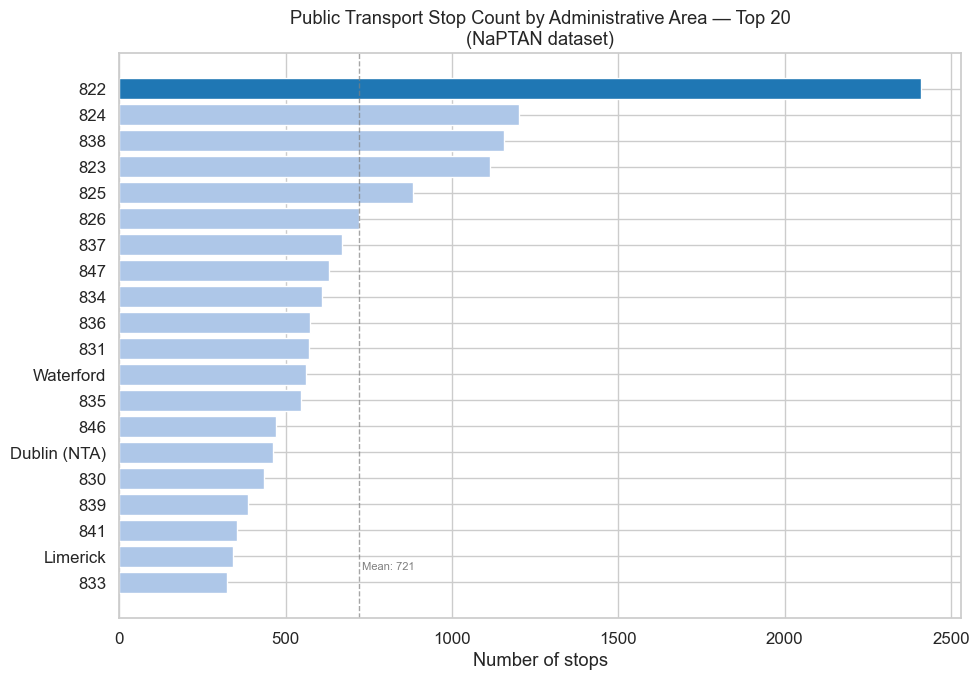

Total active stops in dataset: 17,531
        Area  stop_count
         822        2411
         824        1203
         838        1157
         823        1114
         825         883
         826         721
         837         670
         847         631
         834         609
         836         572
         831         571
   Waterford         560
         835         545
         846         472
Dublin (NTA)         462
         830         434
         839         387
         841         353
    Limerick         341
         833         323


In [25]:
# naptan already loaded from processed
stop_counts = (naptan.groupby("AdministrativeAreaRef")["AtcoCode"]
               .count().reset_index()
               .rename(columns={"AtcoCode": "stop_count"})
               .sort_values("stop_count", ascending=False)
               .head(20))

# Irish NTA admin area codes — top ones
area_labels = {
    849: "Dublin (NTA)", 850: "Cork", 851: "Limerick",
    852: "Galway", 853: "Waterford", 854: "Kilkenny",
    701: "Donegal", 855: "Sligo", 856: "Mayo",
}
stop_counts["Area"] = (stop_counts["AdministrativeAreaRef"]
                       .map(area_labels)
                       .fillna(stop_counts["AdministrativeAreaRef"].astype(str)))

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#1f77b4" if i == 0 else "#aec7e8" for i in range(len(stop_counts))]
ax.barh(stop_counts["Area"][::-1], stop_counts["stop_count"][::-1],
        color=colors[::-1], edgecolor="white")
ax.set(title="Public Transport Stop Count by Administrative Area — Top 20\n(NaPTAN dataset)",
       xlabel="Number of stops", ylabel="")
ax.axvline(stop_counts["stop_count"].mean(), color="grey",
           linestyle="--", linewidth=1, alpha=0.7)
ax.text(stop_counts["stop_count"].mean() + 10, 0.5,
        f"Mean: {stop_counts['stop_count'].mean():.0f}", fontsize=8, color="grey")
plt.tight_layout()
plt.savefig(FIG_DIR / "18_naptan_stops_by_area.png", dpi=150)
plt.show()
print(f"Total active stops in dataset: {len(naptan):,}")
print(stop_counts[["Area","stop_count"]].to_string(index=False))

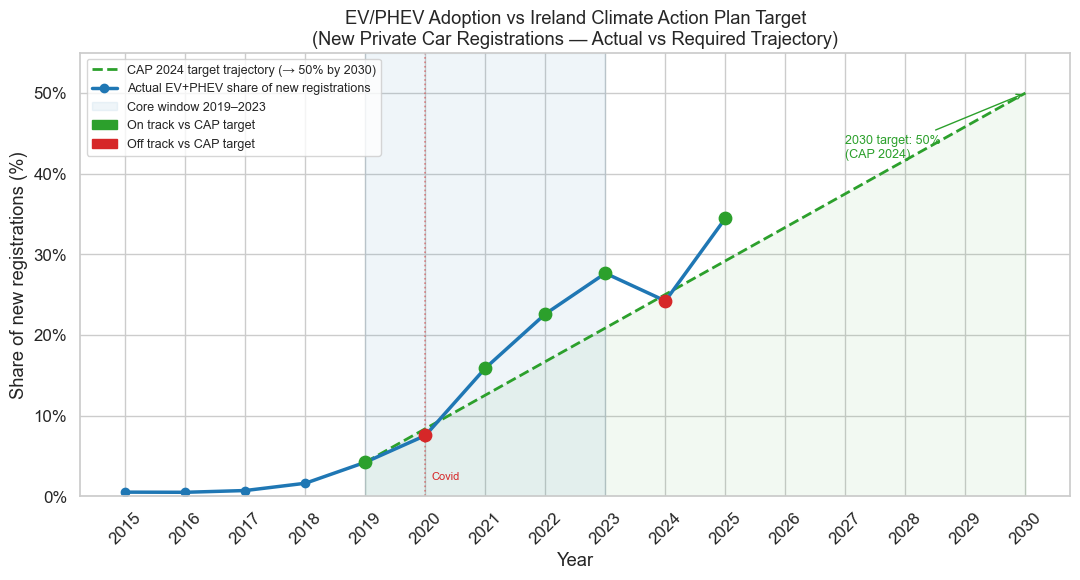

Core window gap analysis (negative = off track):
 Year  ev_phev_pct  target_pct  on_track  gap_pp
 2019     4.204581    4.204581      True    0.00
 2020     7.522329    8.367801     False   -0.85
 2021    15.885639   12.531020      True    3.35
 2022    22.604071   16.694240      True    5.91
 2023    27.647670   20.857460      True    6.79


In [26]:
# TILE 22 — EV/PHEV Adoption vs Climate Action Plan Target

# Actual EV+PHEV share from processed data
actual = fuel_ann[fuel_ann["year_complete"]][["Year","ev_phev_share"]].copy()
actual["ev_phev_pct"] = actual["ev_phev_share"] * 100

# Ireland CAP 2024 target: 50% of new car registrations by 2030
# Baseline: use actual 2019 value as start point
base_year  = 2019
target_year = 2030
target_pct  = 50.0
base_pct    = actual.loc[actual["Year"] == base_year, "ev_phev_pct"].values[0]

# Linear interpolation of required annual milestones 2019 to 2030
target_years = list(range(base_year, target_year + 1))
target_vals  = [base_pct + (target_pct - base_pct) * (y - base_year) /
                (target_year - base_year) for y in target_years]
target_df = pd.DataFrame({"Year": target_years, "target_pct": target_vals})

# Merge actual vs target for core window assessment
merged = actual.merge(target_df, on="Year", how="left")
merged["on_track"] = merged["ev_phev_pct"] >= merged["target_pct"]

fig, ax = plt.subplots(figsize=(11, 6))

# Shaded target corridor
ax.fill_between(target_df["Year"], target_df["target_pct"], 0,
                alpha=0.06, color="#2ca02c", label="_nolegend_")

# Target line
ax.plot(target_df["Year"], target_df["target_pct"],
        linestyle="--", linewidth=2, color="#2ca02c",
        label="CAP 2024 target trajectory (→ 50% by 2030)")

# Actual line
ax.plot(actual["Year"], actual["ev_phev_pct"],
        marker="o", linewidth=2.5, color="#1f77b4",
        label="Actual EV+PHEV share of new registrations")

# Colour each actual point: green = on track, red = off track
for _, row in merged.dropna(subset=["target_pct"]).iterrows():
    color = "#2ca02c" if row["on_track"] else "#d62728"
    ax.scatter(row["Year"], row["ev_phev_pct"],
               color=color, s=80, zorder=5)

# Highlight core window
ax.axvspan(2019, 2023, alpha=0.07, color="#1f77b4", label="Core window 2019–2023")

# Annotate 2030 target
ax.annotate("2030 target: 50%\n(CAP 2024)",
            xy=(2030, 50), xytext=(2027, 42),
            fontsize=9, color="#2ca02c",
            arrowprops=dict(arrowstyle="->", color="#2ca02c"))

# Covid line
ax.axvline(2020, color=COVID_COLOR, linestyle=":", alpha=0.5, linewidth=1.2)
ax.text(2020.1, 2, "Covid", color=COVID_COLOR, fontsize=8)

# On track / off track legend patches
from matplotlib.patches import Patch
legend_extra = [
    Patch(color="#2ca02c", label="On track vs CAP target"),
    Patch(color="#d62728", label="Off track vs CAP target"),
]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles=handles + legend_extra,
          loc="upper left", fontsize=9)

ax.set_xticks(range(int(actual["Year"].min()), 2031))
ax.set_xticklabels(range(int(actual["Year"].min()), 2031), rotation=45)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.set(title="EV/PHEV Adoption vs Ireland Climate Action Plan Target\n"
             "(New Private Car Registrations — Actual vs Required Trajectory)",
       xlabel="Year", ylabel="Share of new registrations (%)")
ax.set_ylim(0, 55)

plt.tight_layout()
plt.savefig(FIG_DIR / "19_ev_adoption_vs_cap_target.png", dpi=150)
plt.show()

# Print gap table for core window
print("Core window gap analysis (negative = off track):")
core_gap = merged[merged["Year"].between(2019, 2023)][
    ["Year","ev_phev_pct","target_pct","on_track"]].copy()
core_gap["gap_pp"] = (core_gap["ev_phev_pct"] - core_gap["target_pct"]).round(2)
print(core_gap.to_string(index=False))